# Import

In [1]:
from scope_singleshot import acquire
from plotter_singleshot import plot_acquisition
from visibility_analyzer import analyze_visibility

# Acquiring

In [ ]:
# ACQUISITION PARAMETERS CONFIGURATION.

acquisition_config = {
    'OSCILLOSCOPE_IP': '169.254.235.175',
    'V_DIV_CH1': 5,      
    'V_DIV_CH2': 5,      
    'T_DIV': 10,          
    'PROBE_ATT': 10,
    'TRIG_LEVEL': 5,     
    'TRIG_CH': 'C1',
    'ARDUINO_PORT': '/dev/ttyACM0',
    'LASER_WAIT_SEC': 10.0,
    'KAPTON_PWM': 0.30,
    'MAX_JOULES': 500, # 0.30 a 400 è quello che funzionava meglio
}

# Acquiring.
base_path = acquire(acquisition_config)


      CONTROLLO SICUREZZA TERMODINAMICA
  Potenza Impostata: 30% -> 4.2 W
  Budget Sicurezza : 400 Joule
  Tempo Max Kapton : 95.24 secondi

Inizializzazione Arduino su /dev/ttyACM0 (Modalità Open-Loop Potenza)...
Connessione all'oscilloscopio in corso...
Connected to: Siglent Technologies,SDS824X HD,SDS08A0Q910156,4.8.12.1.1.6.5
Configuring parameters...
Accensione Laser... Attesa 10.0s per assestamento.
Starting single acquisition. Total time window: 100 s.
Oscilloscope status: Arm
Oscilloscopio ARMATO: Accensione Kapton al 30%!
Oscilloscope status: Ready
Oscilloscope status: Trig'd
Trigger detected! Acquiring remaining 90 seconds...
Acquiring: [██████████████████████████████████████░░] 96.7%
[!!! SICUREZZA !!!] Raggiunti i 400 Joule! Spegnimento Kapton forzato.
Acquiring: [████████████████████████████████████████] 100.0%
Acquisition completed!
Spegnimento totale hardware per evitare surriscaldamento plastico...
Starting download of binary chunks from Oscilloscope...

--- Analyzing 

# Plotting

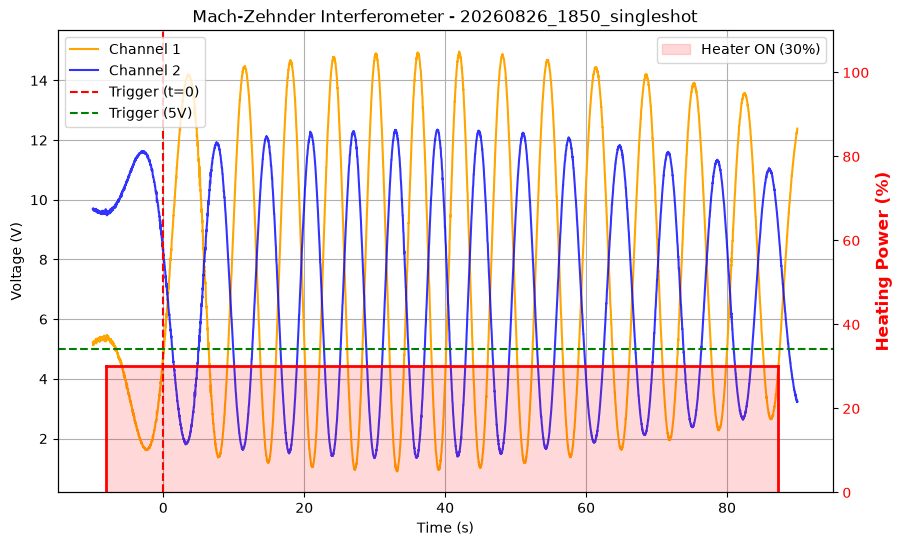

In [3]:
# Plotting.

if base_path:
    
    plot_acquisition(base_path)

# Analyzing

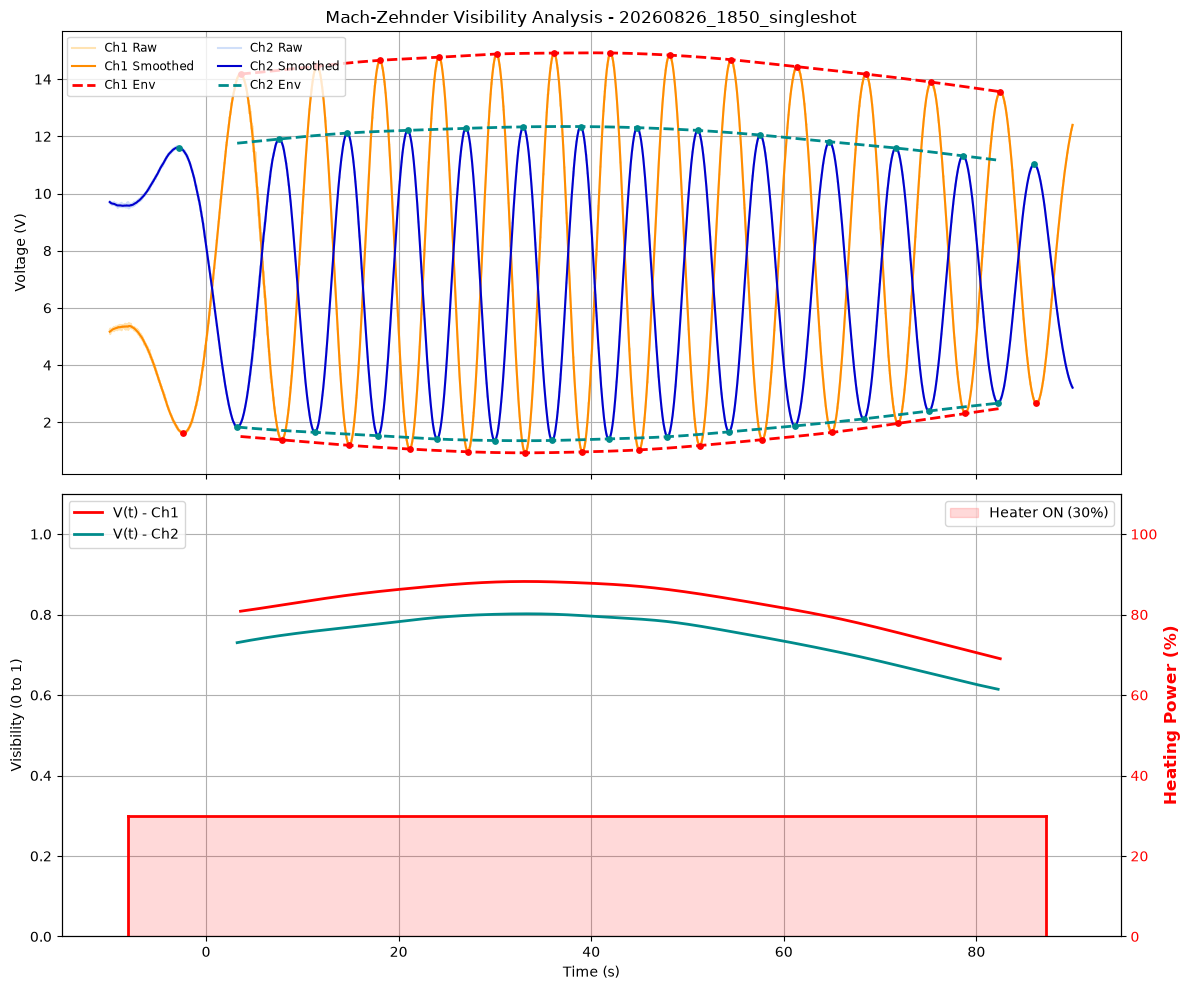

In [4]:
# ANALYSIS PARAMETERS CONFIGURATION.

# "prominence" is the threshold for the peaks, in Volt.
# "savgol_window" is the smoothing amplitude (odd).
# "savgol_poly" is the smoothing polynomial. 

analysis_config = {'prominence': 1.0,
                   'savgol_window': 51,  
                   'savgol_poly': 3
                   }

# Analyzing.

if base_path:

    analyze_visibility(base_path, analysis_config)